In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.convolution import convolve, Gaussian2DKernel, convolve_fft
from scipy.ndimage import zoom
from astropy.visualization import simple_norm

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)

#add rc param for ticks are inwards and minor ticks are on
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)


In [2]:
field = 'NW'

#load in the Halpha map
halpha_fits    = f"../M33-maps/M33-{field}/M33{field}-Haflux.fits"
halpha_amp      = f"../M33-maps/M33-{field}/M33_{field}_amp_nonan.fits"
data = fits.getdata(halpha_amp)

In [3]:
def degrade_map_to_distance(
    image,
    D_orig,
    D_target,
    pixscale_orig,
    fwhm_psf_orig,
    fwhm_instr=None,
    plot=True,
    ax=None   # <-- NEW: optional axis for subplots
):
    """
    Robustly degrade a galaxy emission map to simulate observation at a new distance.
    """

    SCALE = 1e14
    image_scaled = image * SCALE

    mask = np.isnan(image_scaled)
    image_filled = np.nan_to_num(image_scaled, nan=0.0)

    # ---------------------------------------------------
    # 1) Resample
    # ---------------------------------------------------
    scale_factor = D_orig / D_target
    pixscale_new = pixscale_orig / scale_factor

    resampled = zoom(image_filled, scale_factor, order=1)
    mask_resampled = zoom(mask.astype(float), scale_factor, order=0) > 0.5

    # ---------------------------------------------------
    # 2) Compute PSF kernel
    # ---------------------------------------------------
    if fwhm_instr is None:
        fwhm_target = fwhm_psf_orig
    else:
        fwhm_target = fwhm_instr

    def fwhm_to_sigma(f, p):
        return (f/p)/(2*np.sqrt(2*np.log(2)))

    sigma_curr = fwhm_to_sigma(fwhm_psf_orig, pixscale_new)
    sigma_targ = fwhm_to_sigma(fwhm_target, pixscale_new)
    sigma_kernel = np.sqrt(max(0, sigma_targ**2 - sigma_curr**2))

    kernel = Gaussian2DKernel(sigma_kernel if sigma_kernel > 0 else 1e-8)

    # ---------------------------------------------------
    # 3) Convolve
    # ---------------------------------------------------
    degraded = convolve_fft(
        resampled,
        kernel,
        boundary='fill',
        fill_value=0.0,
        preserve_nan=False,
        normalize_kernel=True,
        mask=mask_resampled
    )

    degraded[mask_resampled] = np.nan
    degraded /= SCALE

    # ---------------------------------------------------
    # 4) Spatial Resolution (pc)
    # ---------------------------------------------------
    spatial_resolution_pc = (fwhm_target * D_target * 1e6) / 206265

    # ---------------------------------------------------
    # 5) Plot
    # ---------------------------------------------------
    if plot:
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 12))

        norm = simple_norm(degraded, stretch='log', min_percent=20, max_percent=99)
        im = ax.imshow(degraded, origin='lower', cmap='rainbow', norm=norm)

        # ax.set_title(f"{D_target} Mpc")
        ax.text(
            0.03, 0.97,
            f"Dist: {D_target} Mpc\nRes: {spatial_resolution_pc:.1f} pc",
            color="k",
            fontsize=20,
            #backgorund color white with some transparency
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2),
            transform=ax.transAxes,
            ha="left", va="top"
        )
        
        #turn off axis labels
        ax.set_xticks([])
        ax.set_yticks([])

        if ax is None:
            plt.colorbar(im, ax=ax)
            plt.tight_layout()

    return degraded, pixscale_new, spatial_resolution_pc


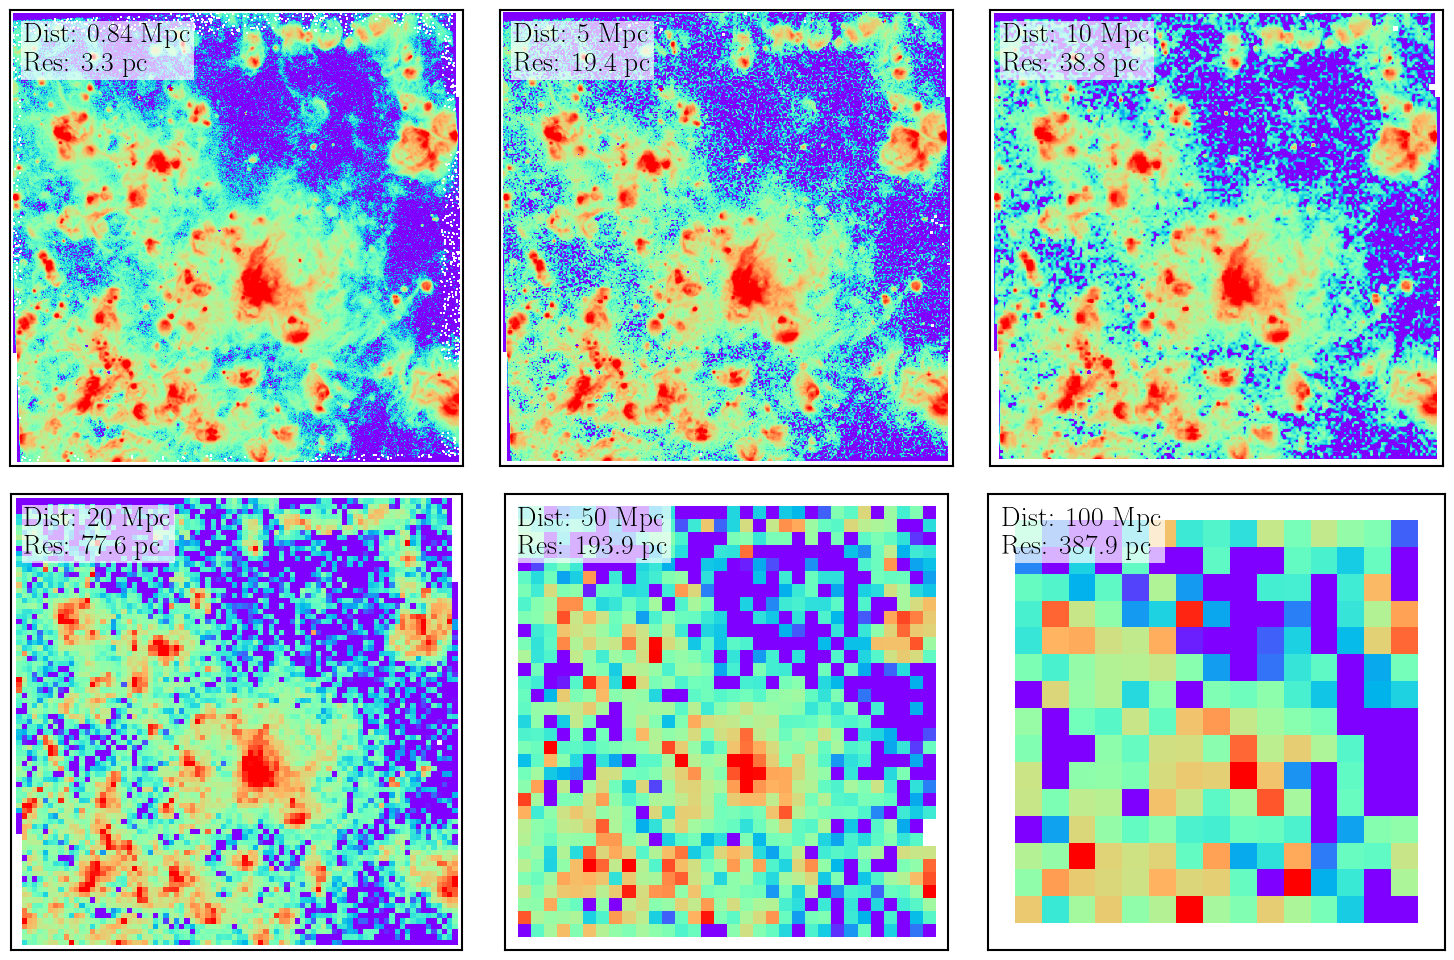

In [4]:
D_orig = 0.84        # M33 distance (Mpc)
pixscale_orig = 0.3 # arcsec/pixel
fwhm_psf_orig = 0.8 # arcsec
D_targets = [D_orig, 5, 10, 20, 50, 100]

n = len(D_targets)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()

for i, D_target in enumerate(D_targets):
    degraded, new_pix, spatial_res = degrade_map_to_distance(
        data,
        D_orig=D_orig,
        D_target=D_target,
        pixscale_orig=pixscale_orig,
        fwhm_psf_orig=fwhm_psf_orig,
        fwhm_instr=None,
        plot=True,
        ax=axes[i]   # <-- pass subplot axis
    )

# Remove any unused panels
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("Galaxy Appearance vs Distance (with Spatial Resolution)", fontsize=16)
plt.tight_layout()
plt.savefig(f"plots/{field}_all_distances_subplots.png", dpi=150)
plt.show()

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from astropy.convolution import Gaussian2DKernel, convolve_fft
from astropy.visualization import simple_norm


def degrade_map_to_distance(
    image,
    D_orig,
    D_target,
    pixscale_orig,
    fwhm_psf_orig,
    fwhm_instr=None,
    plot=True,
    ax=None,
    overlay_peaks=True,
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv",
    peak_file_orig="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peak_marker="o",
    peak_color="white",
    peak_size=40,
    peak_edgecolor="black",
    peak_linewidth=0.8,
    wcs=None,
):
    """
    Robustly degrade a galaxy emission map to simulate observation at a new distance,
    and optionally overlay emission peaks from a CSV file.

    Special case:
    - If D_target == D_orig (e.g. 0.84 Mpc), uses peak_file_orig
    - Otherwise uses peaks_dir + peak_filename_template
    """

    def _find_peak_columns(df):
        """
        Try to infer x/y pixel coordinate column names from the CSV.
        """
        possible_x = ["x", "X", "x_pix", "XPIX", "xpeak", "x_peak", "col", "i"]
        possible_y = ["y", "Y", "y_pix", "YPIX", "ypeak", "y_peak", "row", "j"]

        xcol = next((c for c in possible_x if c in df.columns), None)
        ycol = next((c for c in possible_y if c in df.columns), None)

        # fallback: first two numeric columns
        if xcol is None or ycol is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            if len(numeric_cols) >= 2:
                xcol = numeric_cols[0]
                ycol = numeric_cols[1]

        if xcol is None or ycol is None:
            raise ValueError(
                f"Could not identify x/y peak columns in CSV. "
                f"Available columns: {list(df.columns)}"
            )

        return xcol, ycol

    SCALE = 1e14
    image_scaled = image * SCALE

    mask = np.isnan(image_scaled)
    image_filled = np.nan_to_num(image_scaled, nan=0.0)

    # ---------------------------------------------------
    # 1) Resample
    # ---------------------------------------------------
    scale_factor = D_orig / D_target
    pixscale_new = pixscale_orig / scale_factor

    resampled = zoom(image_filled, scale_factor, order=1)
    mask_resampled = zoom(mask.astype(float), scale_factor, order=0) > 0.5

    # ---------------------------------------------------
    # 2) Compute PSF kernel
    # ---------------------------------------------------
    if fwhm_instr is None:
        fwhm_target = fwhm_psf_orig
    else:
        fwhm_target = fwhm_instr

    def fwhm_to_sigma(f, p):
        return (f / p) / (2 * np.sqrt(2 * np.log(2)))

    sigma_curr = fwhm_to_sigma(fwhm_psf_orig, pixscale_new)
    sigma_targ = fwhm_to_sigma(fwhm_target, pixscale_new)
    sigma_kernel = np.sqrt(max(0, sigma_targ**2 - sigma_curr**2))

    kernel = Gaussian2DKernel(sigma_kernel if sigma_kernel > 0 else 1e-8)

    # ---------------------------------------------------
    # 3) Convolve
    # ---------------------------------------------------
    degraded = convolve_fft(
        resampled,
        kernel,
        boundary="fill",
        fill_value=0.0,
        preserve_nan=False,
        normalize_kernel=True,
        mask=mask_resampled,
    )

    degraded[mask_resampled] = np.nan
    degraded /= SCALE

    # ---------------------------------------------------
    # 4) Spatial Resolution (pc)
    # ---------------------------------------------------
    spatial_resolution_pc = (fwhm_target * D_target * 1e6) / 206265

    # ---------------------------------------------------
    # 5) Read peaks
    # ---------------------------------------------------
    peaks = None
    n_peaks = 0

    if overlay_peaks:
        try:
            # special case: original-distance catalog
            if np.isclose(D_target, D_orig):
                peak_file = peak_file_orig
            else:
                if float(D_target).is_integer():
                    dist_str = str(int(D_target))
                else:
                    dist_str = str(D_target)

                peak_file = os.path.join(
                    peaks_dir,
                    peak_filename_template.format(dist=dist_str)
                )

            if os.path.exists(peak_file):
                peaks = pd.read_csv(peak_file)
                n_peaks = len(peaks)
            else:
                print(f"Peak file not found: {peak_file}")

        except Exception as e:
            print(f"Could not read peak file for D_target={D_target}: {e}")

    # ---------------------------------------------------
    # 6) Plot
    # ---------------------------------------------------
    if plot:
        created_fig = False
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 12))
            created_fig = True

        norm = simple_norm(degraded, stretch="log", min_percent=20, max_percent=99)
        im = ax.imshow(degraded, origin="lower", cmap="rainbow", norm=norm)

        ax.text(
            0.03, 0.97,
            f"Dist: {D_target} Mpc\nRes: {spatial_resolution_pc:.1f} pc\n\# Peaks: {n_peaks}",
            color="k",
            fontsize=20,
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=2),
            transform=ax.transAxes,
            ha="left", va="top"
        )

        # overlay peaks
        if overlay_peaks and peaks is not None and len(peaks) > 0:
            try:
                xcol, ycol = _find_peak_columns(peaks)

                ax.scatter(
                    peaks[xcol].values,
                    peaks[ycol].values,
                    s=peak_size,
                    marker=peak_marker,
                    facecolors=peak_color,
                    edgecolors=peak_edgecolor,
                    linewidths=peak_linewidth,
                    zorder=1,
                )
            except Exception as e:
                print(f"Could not overlay peaks for D_target={D_target}: {e}")

        ax.set_xticks([])
        ax.set_yticks([])

        # Border styling
        for spine in ax.spines.values():
            spine.set_linewidth(4)
            if np.isclose(D_target, 50) or np.isclose(D_target, 100):
                spine.set_color("red")
            else:
                spine.set_color("black")  

        if created_fig:
            plt.colorbar(im, ax=ax)
            plt.tight_layout()

    return degraded, pixscale_new, spatial_resolution_pc

<>:163: SyntaxWarning: invalid escape sequence '\#'
<>:163: SyntaxWarning: invalid escape sequence '\#'
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_11019/3170561959.py:163: SyntaxWarning: invalid escape sequence '\#'
  f"Dist: {D_target} Mpc\nRes: {spatial_resolution_pc:.1f} pc\n\# Peaks: {n_peaks}",


Peak file not found: /Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/100Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv


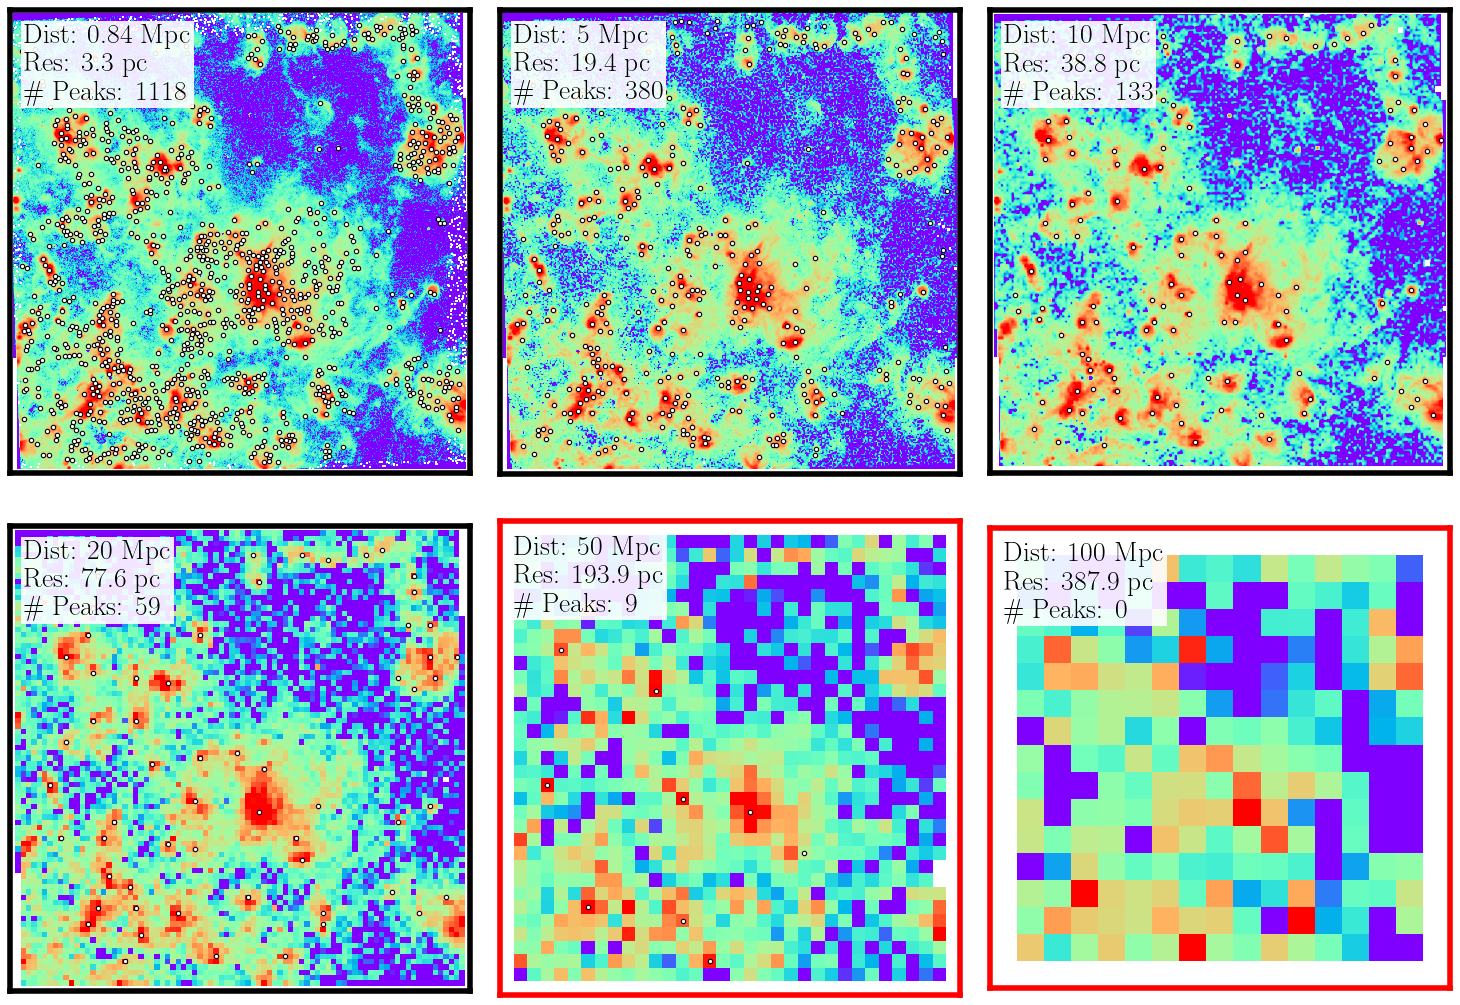

In [222]:
D_orig = 0.84        # M33 distance (Mpc)
pixscale_orig = 0.32 # arcsec/pixel
fwhm_psf_orig = 0.8 # arcsec
D_targets = [D_orig, 5, 10, 20, 50, 100]

nrows = 2
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 11))
axes = axes.flatten()

for i, D_target in enumerate(D_targets):
    degraded, new_pix, spatial_res = degrade_map_to_distance(
        data,
        D_orig=D_orig,
        D_target=D_target,
        pixscale_orig=pixscale_orig,
        fwhm_psf_orig=fwhm_psf_orig,
        fwhm_instr=None,
        plot=True,
        ax=axes[i],
        overlay_peaks=True,
        peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
        peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv",
        peak_file_orig="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
        peak_marker="o",
        peak_color="white",
        peak_edgecolor="k",
        peak_size=10,
    )

# Remove any unused panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"PAPER_PLOTS/{field}_all_distances_subplots.png", dpi=150)
plt.show()

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree


def find_peak_columns(df):
    """
    Try to infer x/y pixel coordinate column names.
    Adjust these lists if your CSVs use different names.
    """
    possible_x = ["x", "X", "x_pix", "XPIX", "xpeak", "x_peak", "col", "i"]
    possible_y = ["y", "Y", "y_pix", "YPIX", "ypeak", "y_peak", "row", "j"]

    xcol = next((c for c in possible_x if c in df.columns), None)
    ycol = next((c for c in possible_y if c in df.columns), None)

    if xcol is None or ycol is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) >= 2:
            xcol, ycol = numeric_cols[0], numeric_cols[1]

    if xcol is None or ycol is None:
        raise ValueError(f"Could not identify x/y columns. Found: {list(df.columns)}")

    return xcol, ycol


def load_peak_catalog_for_distance(
    D_target,
    D_orig=0.84,
    orig_file="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv"
):
    """
    Load the peak catalog for a given distance.
    """
    if np.isclose(D_target, D_orig):
        peak_file = orig_file
    else:
        if float(D_target).is_integer():
            dist_str = str(int(D_target))
        else:
            dist_str = str(D_target)
        peak_file = os.path.join(peaks_dir, peak_filename_template.format(dist=dist_str))

    if not os.path.exists(peak_file):
        raise FileNotFoundError(f"Peak file not found: {peak_file}")

    df = pd.read_csv(peak_file)
    xcol, ycol = find_peak_columns(df)

    coords = df[[xcol, ycol]].to_numpy(dtype=float)
    return df, coords, peak_file, xcol, ycol


def analyze_peak_survival_and_merging(
    D_targets,
    D_orig=0.84,
    match_radius_pix=5.0,
    orig_file="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv"
):
    """
    Compare peak catalogs at different distances to the original catalog.

    Definitions used here:
    - surviving_original_peaks:
        number of original peaks that have at least one degraded peak within match_radius_pix
    - matched_degraded_peaks:
        number of degraded peaks that match at least one original peak
    - merged_degraded_peaks:
        number of degraded peaks that match 2 or more original peaks
    - lost_original_peaks:
        original peaks with no degraded counterpart within match radius
    """

    # load original catalog
    df_orig, coords_orig, orig_path, xcol0, ycol0 = load_peak_catalog_for_distance(
        D_orig,
        D_orig=D_orig,
        orig_file=orig_file,
        peaks_dir=peaks_dir,
        peak_filename_template=peak_filename_template
    )

    tree_orig = cKDTree(coords_orig)
    n_orig = len(coords_orig)

    results = []

    for D in D_targets:
        df_deg, coords_deg, peak_path, xcol, ycol = load_peak_catalog_for_distance(
            D,
            D_orig=D_orig,
            orig_file=orig_file,
            peaks_dir=peaks_dir,
            peak_filename_template=peak_filename_template
        )

        n_deg = len(coords_deg)

        # For each degraded peak, find all original peaks within radius
        if n_deg > 0 and n_orig > 0:
            matches_deg_to_orig = tree_orig.query_ball_point(coords_deg, r=match_radius_pix)
        else:
            matches_deg_to_orig = []

        n_matched_deg = sum(len(m) >= 1 for m in matches_deg_to_orig)
        n_merged_deg = sum(len(m) >= 2 for m in matches_deg_to_orig)

        # Which original peaks are recovered by at least one degraded peak?
        recovered_orig_idx = set()
        for m in matches_deg_to_orig:
            recovered_orig_idx.update(m)

        n_surviving_orig = len(recovered_orig_idx)
        n_lost_orig = n_orig - n_surviving_orig

        results.append({
            "distance_mpc": D,
            "n_original_peaks": n_orig,
            "n_detected_peaks": n_deg,
            "matched_degraded_peaks": n_matched_deg,
            "merged_degraded_peaks": n_merged_deg,
            "surviving_original_peaks": n_surviving_orig,
            "lost_original_peaks": n_lost_orig,
            "survival_fraction": n_surviving_orig / n_orig if n_orig > 0 else np.nan,
            "merge_fraction_of_detected": n_merged_deg / n_deg if n_deg > 0 else np.nan,
            "catalog_file": peak_path,
        })

    return pd.DataFrame(results)

In [7]:
D_targets = [0.84, 5, 10, 20, 35, 50]

results = analyze_peak_survival_and_merging(
    D_targets=D_targets,
    D_orig=0.84,
    match_radius_pix=5.0,   # try a few values: 3, 5, 8
    orig_file="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv"
)

print(results)

   distance_mpc  n_original_peaks  n_detected_peaks  matched_degraded_peaks  \
0          0.84              1118              1118                    1118   
1          5.00              1118               380                       6   
2         10.00              1118               133                       1   
3         20.00              1118                59                       0   
4         35.00              1118                21                       0   
5         50.00              1118                 9                       0   

   merged_degraded_peaks  surviving_original_peaks  lost_original_peaks  \
0                      0                      1118                    0   
1                      0                         5                 1113   
2                      0                         1                 1117   
3                      0                         0                 1118   
4                      0                         0                 1118

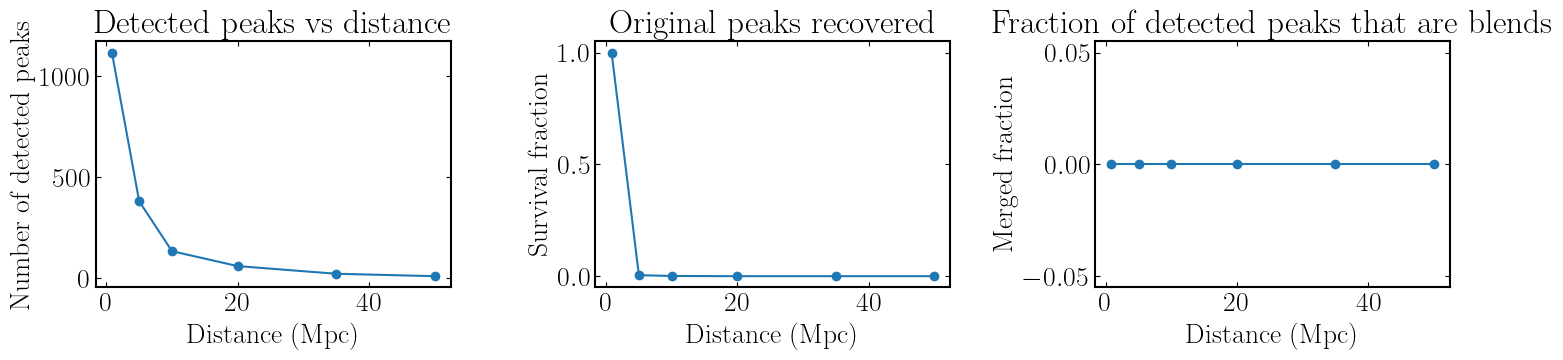

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# number of detected peaks
axes[0].plot(results["distance_mpc"], results["n_detected_peaks"], marker="o")
axes[0].set_xlabel("Distance (Mpc)")
axes[0].set_ylabel("Number of detected peaks")
axes[0].set_title("Detected peaks vs distance")

# survival fraction
axes[1].plot(results["distance_mpc"], results["survival_fraction"], marker="o")
axes[1].set_xlabel("Distance (Mpc)")
axes[1].set_ylabel("Survival fraction")
axes[1].set_title("Original peaks recovered")

# merging fraction
axes[2].plot(results["distance_mpc"], results["merge_fraction_of_detected"], marker="o")
axes[2].set_xlabel("Distance (Mpc)")
axes[2].set_ylabel("Merged fraction")
axes[2].set_title("Fraction of detected peaks that are blends")

plt.tight_layout()
plt.show()

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from astropy.convolution import Gaussian2DKernel, convolve_fft
from astropy.visualization import simple_norm


# ------------------------------------------------------------
# Your degrading function
# ------------------------------------------------------------
def degrade_map_to_distance(
    image,
    D_orig,
    D_target,
    pixscale_orig,
    fwhm_psf_orig,
    fwhm_instr=None,
    plot=True,
    ax=None,
    overlay_peaks=True,
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv",
    peak_file_orig="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peak_marker="o",
    peak_color="white",
    peak_size=40,
    peak_edgecolor="black",
    peak_linewidth=0.8,
):
    def _find_peak_columns(df):
        possible_x = ["x", "X", "x_pix", "XPIX", "xpeak", "x_peak", "col", "i"]
        possible_y = ["y", "Y", "y_pix", "YPIX", "ypeak", "y_peak", "row", "j"]

        xcol = next((c for c in possible_x if c in df.columns), None)
        ycol = next((c for c in possible_y if c in df.columns), None)

        if xcol is None or ycol is None:
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            if len(numeric_cols) >= 2:
                xcol = numeric_cols[0]
                ycol = numeric_cols[1]

        if xcol is None or ycol is None:
            raise ValueError(f"Could not identify x/y peak columns. Found: {list(df.columns)}")

        return xcol, ycol

    SCALE = 1e14
    image_scaled = image * SCALE

    mask = np.isnan(image_scaled)
    image_filled = np.nan_to_num(image_scaled, nan=0.0)

    scale_factor = D_orig / D_target
    pixscale_new = pixscale_orig / scale_factor

    resampled = zoom(image_filled, scale_factor, order=1)
    mask_resampled = zoom(mask.astype(float), scale_factor, order=0) > 0.5

    if fwhm_instr is None:
        fwhm_target = fwhm_psf_orig
    else:
        fwhm_target = fwhm_instr

    def fwhm_to_sigma(f, p):
        return (f / p) / (2 * np.sqrt(2 * np.log(2)))

    sigma_curr = fwhm_to_sigma(fwhm_psf_orig, pixscale_new)
    sigma_targ = fwhm_to_sigma(fwhm_target, pixscale_new)
    sigma_kernel = np.sqrt(max(0, sigma_targ**2 - sigma_curr**2))

    kernel = Gaussian2DKernel(sigma_kernel if sigma_kernel > 0 else 1e-8)

    degraded = convolve_fft(
        resampled,
        kernel,
        boundary="fill",
        fill_value=0.0,
        preserve_nan=False,
        normalize_kernel=True,
        mask=mask_resampled,
    )

    degraded[mask_resampled] = np.nan
    degraded /= SCALE

    spatial_resolution_pc = (fwhm_target * D_target * 1e6) / 206265

    peaks = None
    n_peaks = 0

    if overlay_peaks:
        try:
            if np.isclose(D_target, D_orig):
                peak_file = peak_file_orig
            else:
                if float(D_target).is_integer():
                    dist_str = str(int(D_target))
                else:
                    dist_str = str(D_target)

                peak_file = os.path.join(
                    peaks_dir,
                    peak_filename_template.format(dist=dist_str)
                )

            if os.path.exists(peak_file):
                peaks = pd.read_csv(peak_file)
                n_peaks = len(peaks)
            else:
                print(f"Peak file not found: {peak_file}")

        except Exception as e:
            print(f"Could not read peak file for D_target={D_target}: {e}")

    if plot:
        created_fig = False
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 12))
            created_fig = True

        norm = simple_norm(degraded, stretch="log", min_percent=20, max_percent=99)
        im = ax.imshow(degraded, origin="lower", cmap="rainbow", norm=norm)

        ax.text(
            0.03, 0.97,
            f"Dist: {D_target} Mpc\nRes: {spatial_resolution_pc:.1f} pc\n# Peaks: {n_peaks}",
            color="k",
            fontsize=20,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
            transform=ax.transAxes,
            ha="left", va="top"
        )

        if overlay_peaks and peaks is not None and len(peaks) > 0:
            try:
                xcol, ycol = _find_peak_columns(peaks)
                ax.scatter(
                    peaks[xcol].values,
                    peaks[ycol].values,
                    s=peak_size,
                    marker=peak_marker,
                    facecolors=peak_color,
                    edgecolors=peak_edgecolor,
                    linewidths=peak_linewidth,
                    zorder=5,
                )
            except Exception as e:
                print(f"Could not overlay peaks for D_target={D_target}: {e}")

        ax.set_xticks([])
        ax.set_yticks([])

        if created_fig:
            plt.colorbar(im, ax=ax)
            plt.tight_layout()

    return degraded, pixscale_new, spatial_resolution_pc


# ------------------------------------------------------------
# Helpers for luminosity function work
# ------------------------------------------------------------
def find_peak_columns(df):
    possible_x = ["x", "X", "x_pix", "XPIX", "xpeak", "x_peak", "col", "i"]
    possible_y = ["y", "Y", "y_pix", "YPIX", "ypeak", "y_peak", "row", "j"]

    xcol = next((c for c in possible_x if c in df.columns), None)
    ycol = next((c for c in possible_y if c in df.columns), None)

    if xcol is None or ycol is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) >= 2:
            xcol, ycol = numeric_cols[0], numeric_cols[1]

    if xcol is None or ycol is None:
        raise ValueError(f"Could not identify x/y columns. Found: {list(df.columns)}")

    return xcol, ycol


def load_peak_catalog_for_distance(
    D_target,
    D_orig=0.84,
    orig_file="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv"
):
    if np.isclose(D_target, D_orig):
        peak_file = orig_file
    else:
        if float(D_target).is_integer():
            dist_str = str(int(D_target))
        else:
            dist_str = str(D_target)

        peak_file = os.path.join(peaks_dir, peak_filename_template.format(dist=dist_str))

    if not os.path.exists(peak_file):
        raise FileNotFoundError(f"Peak file not found: {peak_file}")

    df = pd.read_csv(peak_file)
    xcol, ycol = find_peak_columns(df)
    return df, xcol, ycol, peak_file


def sample_flux_at_peaks(image, peaks_df, xcol, ycol):
    """
    Sample the image at the nearest pixel to each peak position.
    """
    x = np.rint(peaks_df[xcol].values).astype(int)
    y = np.rint(peaks_df[ycol].values).astype(int)

    good = (
        (x >= 0) & (x < image.shape[1]) &
        (y >= 0) & (y < image.shape[0])
    )

    fluxes = np.full(len(peaks_df), np.nan)
    fluxes[good] = image[y[good], x[good]]

    return fluxes


def flux_to_luminosity(flux, distance_mpc):
    """
    Convert flux to luminosity using L = 4*pi*D^2*F

    distance_mpc -> cm
    """
    mpc_to_cm = 3.085677581e24
    D_cm = distance_mpc * mpc_to_cm
    return 4.0 * np.pi * D_cm**2 * flux


def compute_peak_luminosities_for_distances(
    image,
    D_targets,
    D_orig=0.84,
    pixscale_orig=0.3,
    fwhm_psf_orig=0.8,
    fwhm_instr=None,
    orig_file="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv"
):
    """
    For each distance:
      - degrade map
      - load peak catalog
      - sample peak fluxes from degraded map
      - convert to luminosities
    """
    lum_dict = {}
    flux_dict = {}

    for D_target in D_targets:
        degraded, new_pix, spatial_res = degrade_map_to_distance(
            image,
            D_orig=D_orig,
            D_target=D_target,
            pixscale_orig=pixscale_orig,
            fwhm_psf_orig=fwhm_psf_orig,
            fwhm_instr=fwhm_instr,
            plot=False,
            overlay_peaks=False,
            peaks_dir=peaks_dir,
            peak_filename_template=peak_filename_template,
            peak_file_orig=orig_file,
        )

        peaks_df, xcol, ycol, peak_file = load_peak_catalog_for_distance(
            D_target,
            D_orig=D_orig,
            orig_file=orig_file,
            peaks_dir=peaks_dir,
            peak_filename_template=peak_filename_template
        )

        fluxes = sample_flux_at_peaks(degraded, peaks_df, xcol, ycol)

        # keep only finite positive values for LF work
        good = np.isfinite(fluxes) & (fluxes > 0)
        fluxes = fluxes[good]
        luminosities = flux_to_luminosity(fluxes, D_target)

        flux_dict[D_target] = fluxes
        lum_dict[D_target] = luminosities

        print(f"{D_target} Mpc: {len(luminosities)} valid peak luminosities")

    return lum_dict, flux_dict


def plot_luminosity_functions(
    lum_dict,
    bins=20,
    logL_range=None,
    density=False,
    histtype="step",
    linewidth=2,
    alpha=1.0
):
    """
    Plot all luminosity functions on one panel using rainbow colormap.
    """
    distances = list(lum_dict.keys())
    cmap = plt.cm.rainbow
    colors = cmap(np.linspace(0, 1, len(distances)))

    # gather all luminosities to define common bins
    all_lums = np.concatenate([
        lum_dict[D][np.isfinite(lum_dict[D]) & (lum_dict[D] > 0)]
        for D in distances
        if len(lum_dict[D]) > 0
    ])

    logL_all = np.log10(all_lums)

    if logL_range is None:
        xmin = np.floor(logL_all.min() * 2) / 2
        xmax = np.ceil(logL_all.max() * 2) / 2
    else:
        xmin, xmax = logL_range

    bin_edges = np.linspace(xmin, xmax, bins + 1)

    fig, ax = plt.subplots(figsize=(8, 6))

    for color, D in zip(colors, distances):
        lums = lum_dict[D]
        lums = lums[np.isfinite(lums) & (lums > 0)]

        if len(lums) == 0:
            continue

        logL = np.log10(lums)

        ax.hist(
            logL,
            bins=bin_edges,
            histtype=histtype,
            linewidth=linewidth,
            alpha=alpha,
            density=density,
            color=color,
            label=f"{D} Mpc"
        )

    ax.set_xlabel(r"log$_{10}$(Luminosity)")
    ax.set_ylabel("Density" if density else "Number of peaks")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return fig, ax

0.84 Mpc: 1118 valid peak luminosities
5 Mpc: 380 valid peak luminosities
10 Mpc: 133 valid peak luminosities
20 Mpc: 59 valid peak luminosities
35 Mpc: 21 valid peak luminosities
50 Mpc: 9 valid peak luminosities


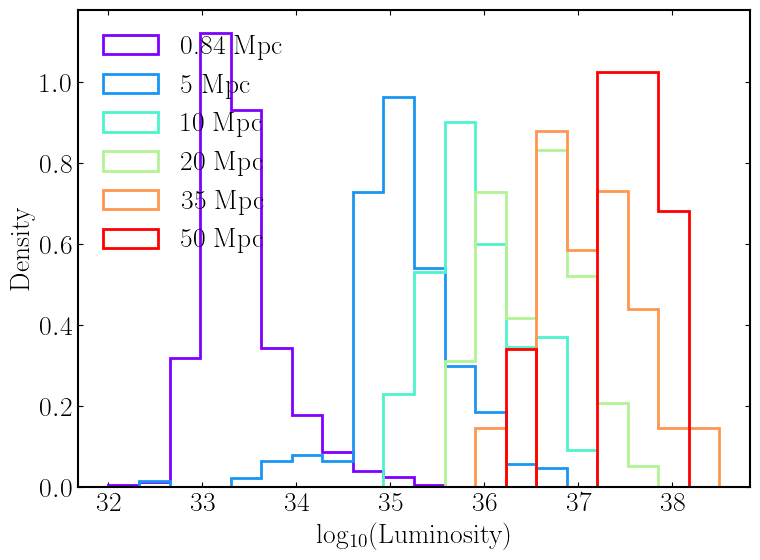

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='log$_{10}$(Luminosity)', ylabel='Density'>)

In [11]:
D_orig = 0.84
pixscale_orig = 0.3
fwhm_psf_orig = 0.8
D_targets = [0.84, 5, 10, 20, 35, 50]

lum_dict, flux_dict = compute_peak_luminosities_for_distances(
    image=data,
    D_targets=D_targets,
    D_orig=D_orig,
    pixscale_orig=pixscale_orig,
    fwhm_psf_orig=fwhm_psf_orig,
    fwhm_instr=None,
    orig_file="/Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/final_peaks_NW.csv",
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv"
)

plot_luminosity_functions(
    lum_dict,
    bins=20,
    density=True,
    histtype="step",
    linewidth=2
)

In [12]:
from m33_pipeline.resolution_regions import (
    build_region_catalogs_for_distances,
    degrade_map_to_distance,
    find_peak_columns,
    load_peak_catalog_for_distance,
    plot_luminosity_functions_from_catalogs,
    plot_luminosity_vs_radius,
    plot_region_size_histograms,
    plot_segmentation_example,
)


In [13]:
D_orig = 0.84
pixscale_orig = 0.3
fwhm_psf_orig = 0.8
D_targets = [0.84, 5, 10, 20, 35, 50]

catalogs, label_maps, degraded_maps, zoi_maps = build_region_catalogs_for_distances(
    image=data,
    d_targets=D_targets,
    field=field,
    d_orig=D_orig,
    pixscale_orig=pixscale_orig,
    fwhm_psf_orig=fwhm_psf_orig,
    fwhm_instr=None,
    orig_file=f"CATALOGS/final_peaks_{field}.csv",
    peaks_dir="/Users/emmajarvis/Documents/SIGNALS/M33/NW-peak-identification/resolution/",
    peak_filename_template="{dist}Mpc_list_pix_A_PicL16_sizd1_facbg1.20_snoi2.00_bg1_30_size1.csv",
    sizebox=1,
    zoi_maxrad_pc=100.0,
    influence_exp=2.0,
    save_region_catalogs=True,
    output_dir="region_catalogs",
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


0.84 Mpc: built 1118 HII regions with notebook 4-5 pipeline


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


5 Mpc: built 380 HII regions with notebook 4-5 pipeline


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


10 Mpc: built 133 HII regions with notebook 4-5 pipeline


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


20 Mpc: built 59 HII regions with notebook 4-5 pipeline
35 Mpc: built 21 HII regions with notebook 4-5 pipeline
50 Mpc: built 9 HII regions with notebook 4-5 pipeline


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='log$_{10}$(Luminosity)', ylabel='Density'>)

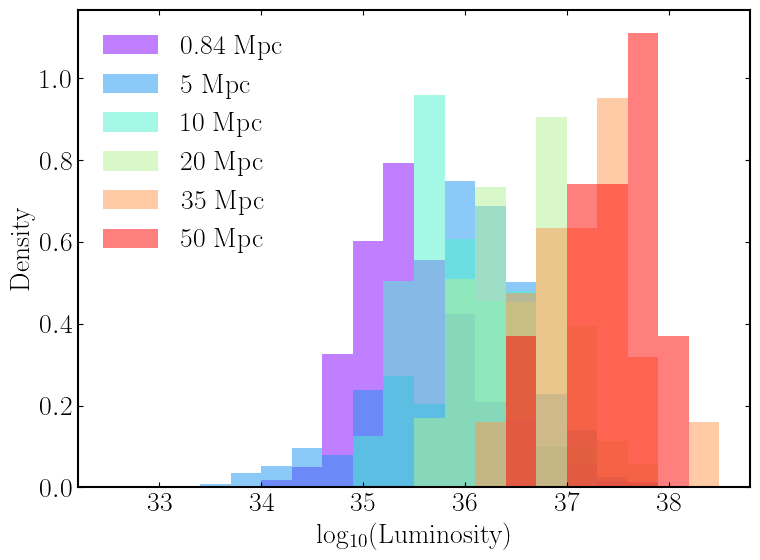

In [14]:
plot_luminosity_functions_from_catalogs(
    catalogs,
    bins=20,
    density=True,
    histtype="stepfilled",
    linewidth=2)

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='R$_{\\rm eq}$ (pc)', ylabel='Density'>)

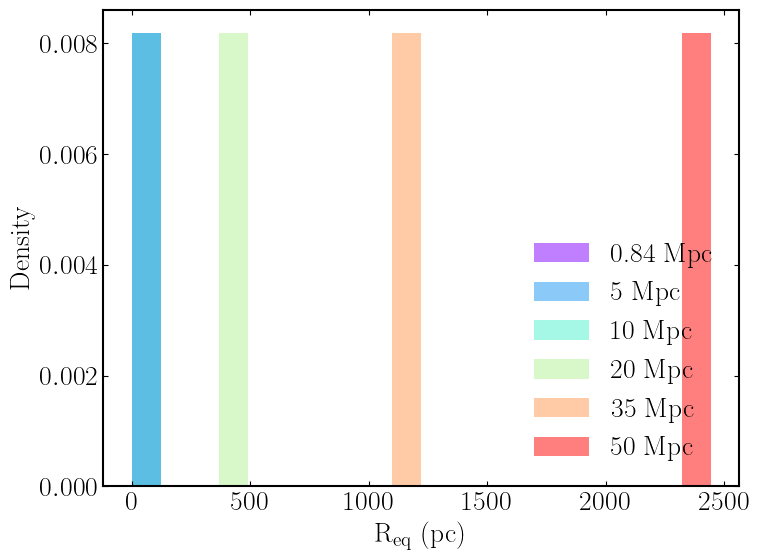

In [15]:
plot_region_size_histograms(
    catalogs,
    bins=20,
    density=True,
    histtype="stepfilled",
    linewidth=2,
    logR=False,   # set True if you prefer log10(radius)
)

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='R$_{\\rm eq}$ (pc)', ylabel='Luminosity'>)

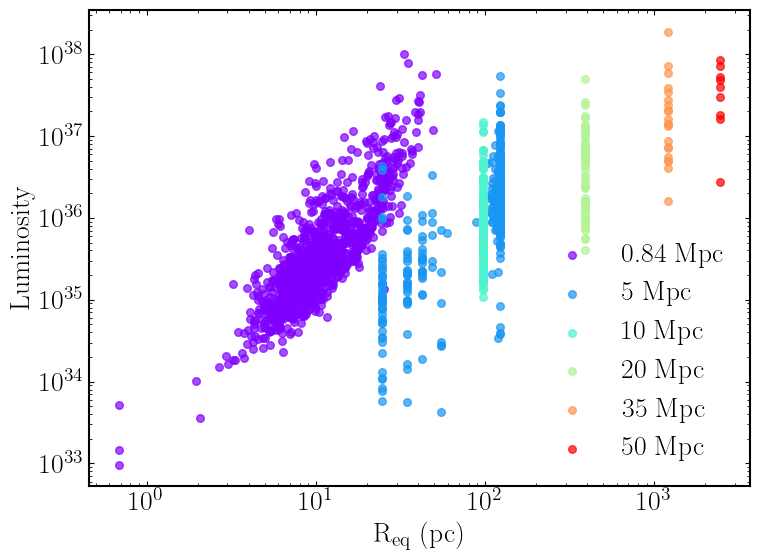

In [16]:
plot_luminosity_vs_radius(
    catalogs,
    logx=True,
    logy=True,
    alpha=0.7,
    s=30,
)

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': '50 Mpc segmentation'}>)

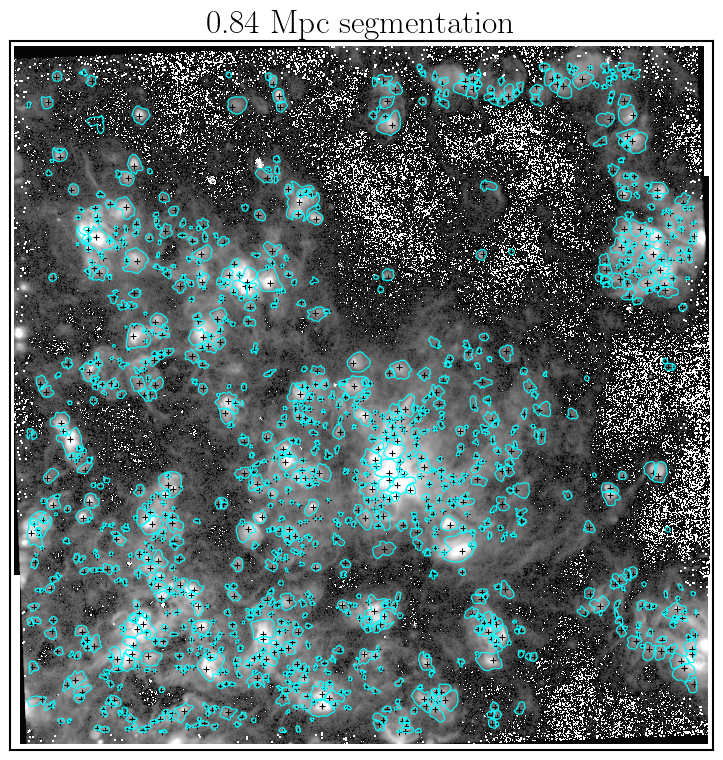

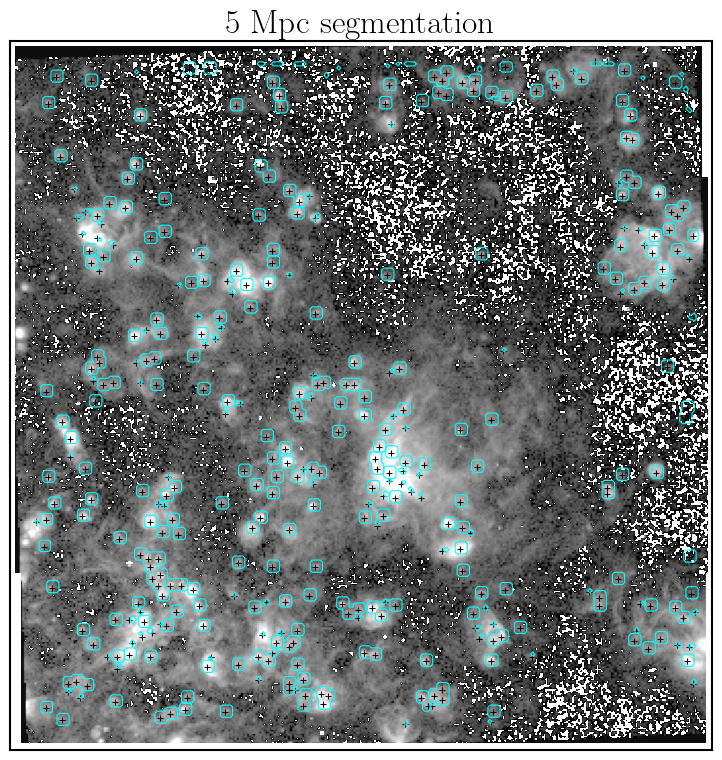

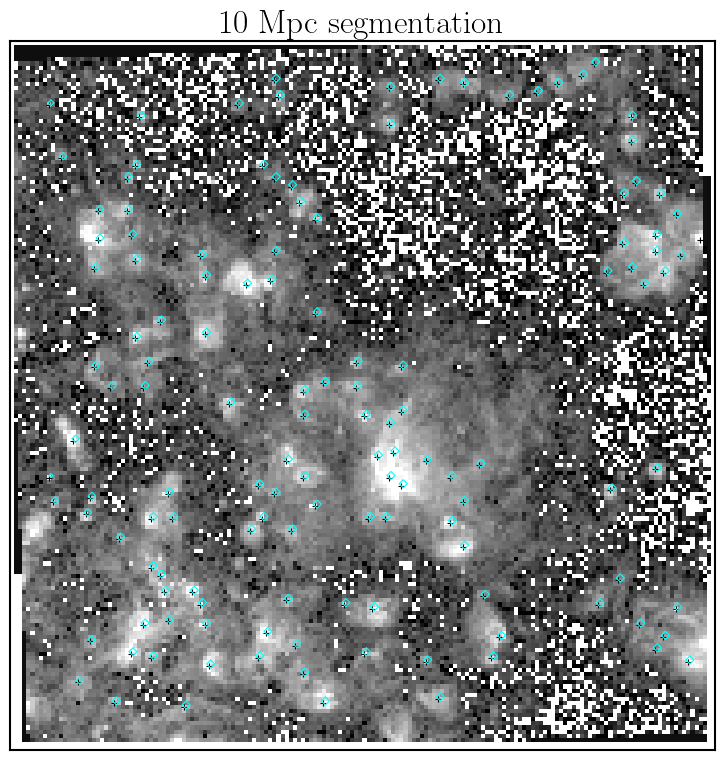

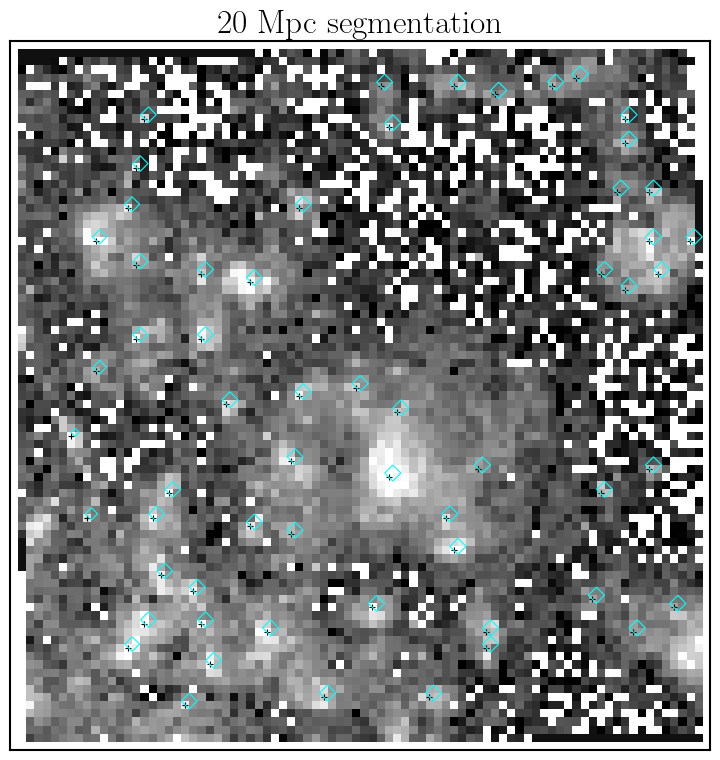

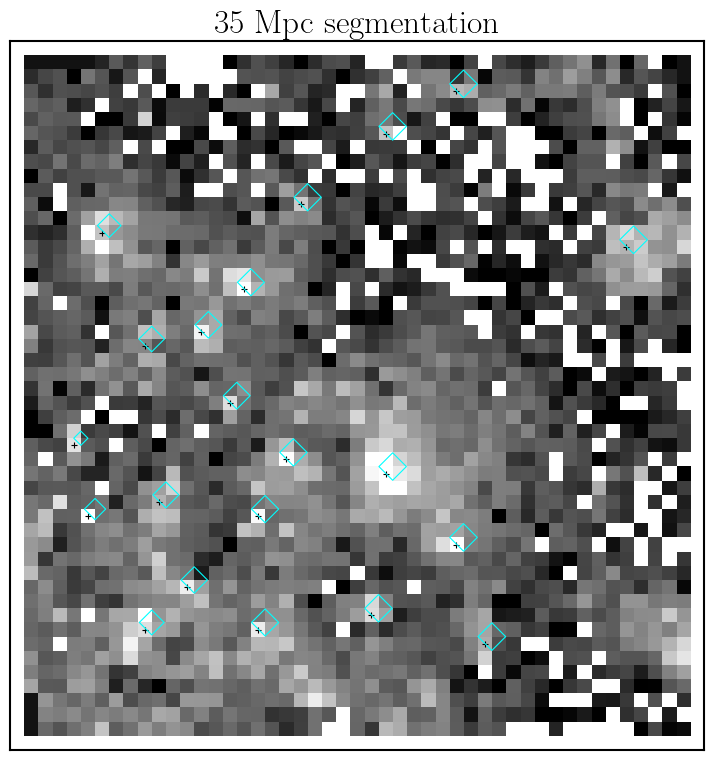

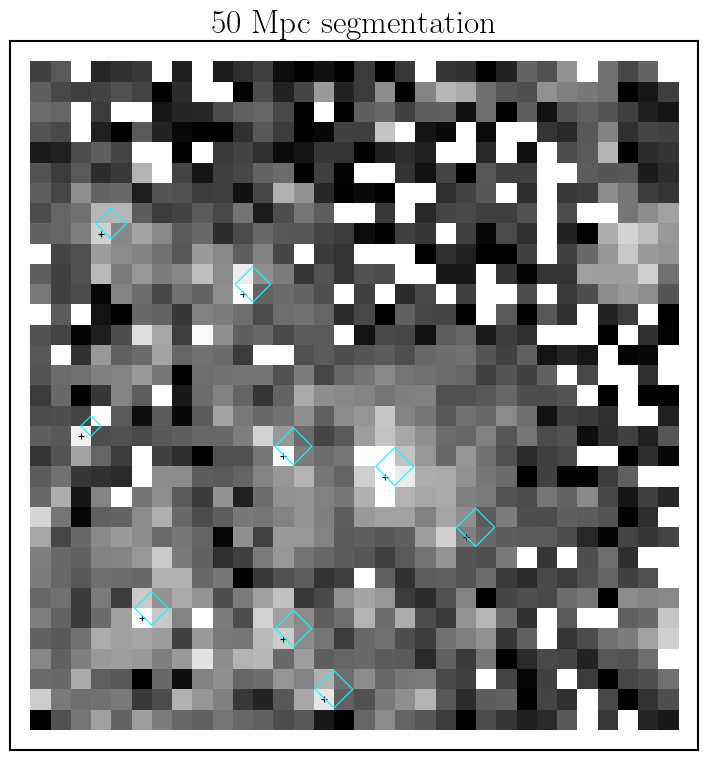

In [17]:
plot_segmentation_example(
    degraded_maps[0.84],
    label_maps[0.84],
    catalogs[0.84],
    title="0.84 Mpc segmentation"
)

plot_segmentation_example(
    degraded_maps[5],
    label_maps[5],
    catalogs[5],
    title="5 Mpc segmentation"
)

plot_segmentation_example(
    degraded_maps[10],
    label_maps[10],
    catalogs[10],
    title="10 Mpc segmentation"
)

plot_segmentation_example(
    degraded_maps[20],
    label_maps[20],
    catalogs[20],
    title="20 Mpc segmentation"
)


plot_segmentation_example(
    degraded_maps[35],
    label_maps[35],
    catalogs[35],
    title="35 Mpc segmentation"
)

plot_segmentation_example(
    degraded_maps[50],
    label_maps[50],
    catalogs[50],
    title="50 Mpc segmentation"
)